# 3K - PCA do bloco de crescimento/acoplamento do Nino 3.4

**Pergunta especifica.** Entre as variaveis que descrevem o CRESCIMENTO e o ACOPLAMENTO dos eventos `forte_p90` e `super_p95`, qual e o conjunto minimo indispensavel de dimensoes fisicas independentes?

**Objetivo.** Reduzir o bloco de crescimento por PCA e identificar 1 representante por componente, expondo a redundancia entre variaveis de recarga.

**Justificativa.** Muitas variaveis medem o mesmo estado fisico. O PCA evita contar a mesma evidencia varias vezes no parecer. Eventos abaixo do P90 nao entram nesta analise.

**Metodologia.** Amostras = semanas em fase de crescimento (onset->pico) apenas dos eventos >P90. Variaveis = SSTA, D20, OHC, SSH, tilt, WWV, tau_x_anom, DHW C-week P90. Padronizacao z-score; PCA; scree, loadings e biplot; representante de maior |loading| por PC ate 90% da variancia.

**Saidas.** `phase3K_pca_variancia.csv`, `phase3K_pca_loadings.csv`, `phase3K_conjunto_indispensavel.csv`, `phase3K_scree.png`, `phase3K_biplot.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import fase3_utils as u

w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_p90_p95()
GROW=['nino34_ssta','d20_m','ohc_0_300','ohc_0_700','ssh_m','tilt_m','wwv','tau_x_anom_nino34_pa','dhw_cweek_p90']
mask=pd.Series(False,index=w.index)
for _,e in ev.iterrows(): mask.loc[e.event_start:e.peak_time]=True
Xdf=w.loc[mask & (w.index>='1993-01-01'), GROW].dropna()
print('amostras de crescimento P90/P95 (1993+):',Xdf.shape,'| eventos=',len(ev))
X=StandardScaler().fit_transform(Xdf.values)
pca=PCA().fit(X); evr=pca.explained_variance_ratio_
var=pd.DataFrame({'componente':[f'PC{i+1}' for i in range(len(evr))],'var_explicada':evr.round(3),'var_acumulada':evr.cumsum().round(3)})
u.save_table(var,'phase3K_pca_variancia.csv',index=False)
load=pd.DataFrame(pca.components_[:4].T,index=Xdf.columns,columns=[f'PC{i+1}' for i in range(4)]).round(3)
u.save_table(load,'phase3K_pca_loadings.csv')
n90=int(np.argmax(evr.cumsum()>=0.90)+1)
print(f'{n90} PCs explicam >=90% (PC1={evr[0]:.2f}, PC2={evr[1]:.2f}, PC3={evr[2]:.2f})')
load


amostras de crescimento P90/P95 (1993+): (179, 9) | eventos= 10
[tabela] data\processed\parquet\statistics\phase3K_pca_variancia.csv
[tabela] data\processed\parquet\statistics\phase3K_pca_loadings.csv
4 PCs explicam >=90% (PC1=0.69, PC2=0.13, PC3=0.07)


,PC1,PC2,PC3,PC4
nino34_ssta,0.356,-0.162,0.363,-0.304
d20_m,0.320,0.356,-0.521,0.182
ohc_0_300,0.391,0.110,-0.236,-0.006
ohc_0_700,0.384,0.113,-0.249,-0.082
ssh_m,0.381,0.047,-0.050,-0.157
tilt_m,0.330,-0.345,-0.034,0.005
wwv,0.160,0.698,0.569,0.317
tau_x_anom_nino34_pa,0.262,-0.447,0.146,0.795
dhw_cweek_p90,0.349,-0.117,0.361,-0.334


In [2]:
# conjunto indispensavel: representante distinto por PC ate 90%
picked=[]; rows=[]
sig={'PC1':'recarga/subsuperficie (amplitude)','PC2':'acoplamento vento-superficie','PC3':'forcante independente'}
for pc in [f'PC{i+1}' for i in range(n90)]:
    s=load[pc].abs().sort_values(ascending=False)
    for v in s.index:
        if v not in picked: picked.append(v); rows.append({'PC':pc,'representante':v,'|loading|':round(s[v],3),'interpretacao':sig.get(pc,'-')}); break
ind=pd.DataFrame(rows); u.save_table(ind,'phase3K_conjunto_indispensavel.csv',index=False)
ind

[tabela] data\processed\parquet\statistics\phase3K_conjunto_indispensavel.csv


,PC,representante,|loading|,interpretacao
0,PC1,ohc_0_300,0.391,recarga/subsuperficie (amplitude)
1,PC2,wwv,0.698,acoplamento vento-superficie
2,PC3,d20_m,0.521,forcante independente
3,PC4,tau_x_anom_nino34_pa,0.795,-


[figura] data\processed\figures\fase3\phase3K_scree.png


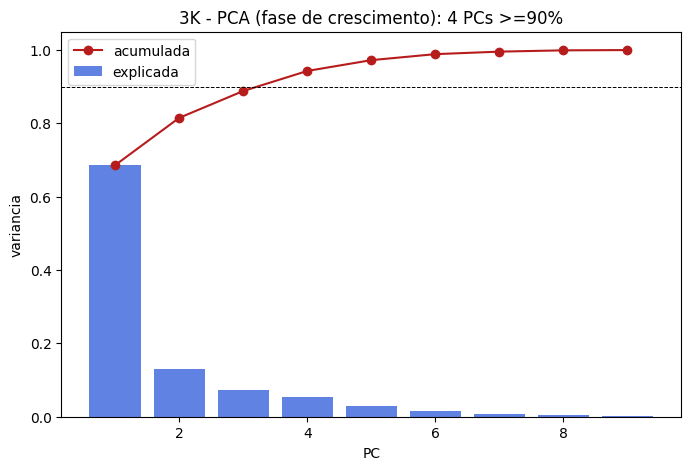

In [3]:
# scree
fig,ax=plt.subplots(figsize=(8,5)); x=range(1,len(evr)+1)
ax.bar(x,evr,color='#1d4ed8',alpha=.7,label='explicada'); ax.plot(x,evr.cumsum(),'o-',color='#b71c1c',label='acumulada')
ax.axhline(.9,ls='--',color='k',lw=.7); ax.set_xlabel('PC'); ax.set_ylabel('variancia'); ax.legend()
ax.set_title(f'3K - PCA (fase de crescimento): {n90} PCs >=90%'); u.save_fig(fig,'phase3K_scree.png'); plt.show()

[figura] data\processed\figures\fase3\phase3K_biplot.png


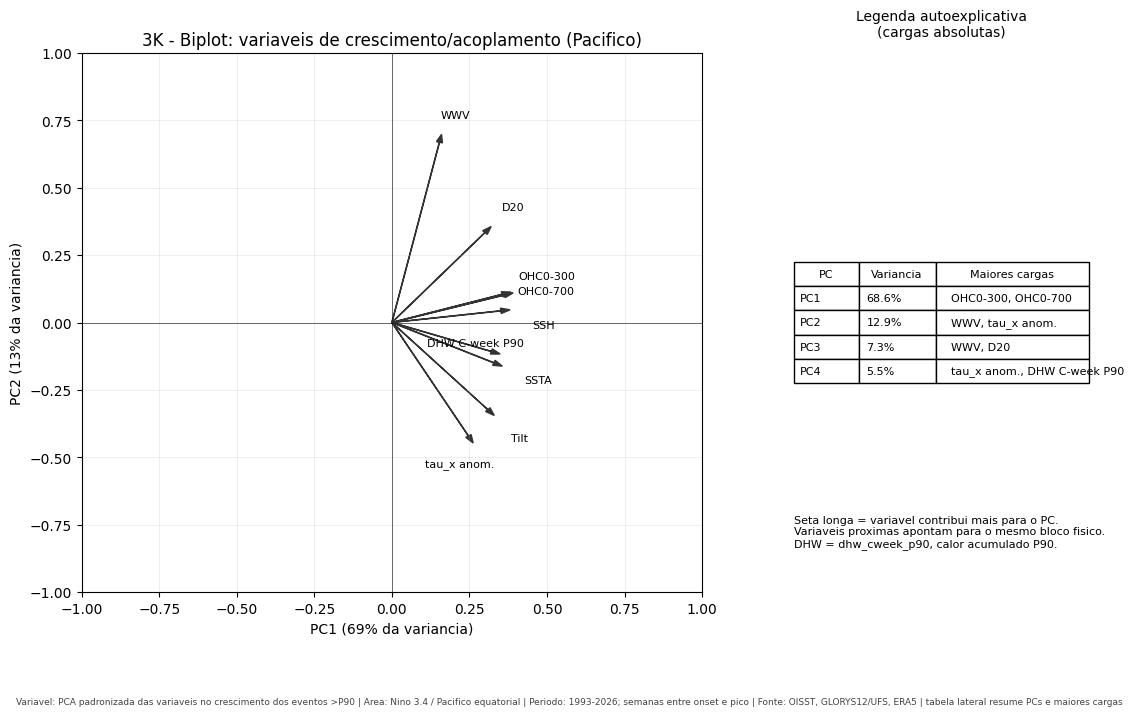

In [4]:
# biplot PC1xPC2 com tabela de leitura ao lado
fig,(ax,ax_tbl)=plt.subplots(1,2,figsize=(13,7),gridspec_kw={'width_ratios':[2.1,1]})
offsets={
    'nino34_ssta':(26,-10),'dhw_cweek_p90':(-18,8),'ohc_0_300':(24,12),'ohc_0_700':(25,1),
    'ssh_m':(24,-11),'tau_x_anom_nino34_pa':(-10,-16),'tilt_m':(18,-16),'wwv':(10,14),'d20_m':(16,14)
}
for v in Xdf.columns:
    x,y=load.loc[v,'PC1'],load.loc[v,'PC2']
    ax.arrow(0,0,x,y,head_width=.02,color='#333',length_includes_head=True)
    dx,dy=offsets.get(v,(8,8))
    ax.annotate(u.var_label(v,short=True),xy=(x,y),xytext=(dx,dy),textcoords='offset points',fontsize=8,ha='center',va='center')
ax.axhline(0,color='k',lw=.4); ax.axvline(0,color='k',lw=.4); ax.set_xlim(-1,1); ax.set_ylim(-1,1)
ax.set_xlabel(f'PC1 ({evr[0]*100:.0f}% da variancia)'); ax.set_ylabel(f'PC2 ({evr[1]*100:.0f}% da variancia)')
ax.set_title('3K - Biplot: variaveis de crescimento/acoplamento (Pacifico)')
ax.grid(alpha=.2)
ax_tbl.axis('off')
legend_rows=[]
for pc in [f'PC{i+1}' for i in range(min(n90,4))]:
    top=load[pc].abs().sort_values(ascending=False).head(2)
    legend_rows.append([pc, f"{evr[int(pc[2:])-1]*100:.1f}%", ', '.join(u.var_label(v,short=True) for v in top.index)])
table=ax_tbl.table(cellText=legend_rows,colLabels=['PC','Variancia','Maiores cargas'],loc='center',cellLoc='left',colWidths=[.22,.26,.52])
table.auto_set_font_size(False); table.set_fontsize(8); table.scale(1,1.45)
ax_tbl.set_title('Legenda autoexplicativa\n(cargas absolutas)',fontsize=10,pad=12)
ax_tbl.text(0,0.08,'Seta longa = variavel contribui mais para o PC.\nVariaveis proximas apontam para o mesmo bloco fisico.\nDHW = dhw_cweek_p90, calor acumulado P90.',fontsize=8,va='bottom')
u.stamp_caption(fig,variavel='PCA padronizada das variaveis no crescimento dos eventos >P90',area='Nino 3.4 / Pacifico equatorial',periodo='1993-2026; semanas entre onset e pico',fonte='OISST, GLORYS12/UFS, ERA5',extra='tabela lateral resume PCs e maiores cargas')
u.save_fig(fig,'phase3K_biplot.png'); plt.show()


In [5]:
# Explicacao das variaveis por tras de cada PC (nao basta a % - importa QUEM carrega)
load_abs=load.abs()
print('Variancia:', ' '.join(f'PC{i+1}={evr[i]*100:.0f}%' for i in range(min(4,len(evr)))),
      f'| {n90} PCs = {evr[:n90].sum()*100:.0f}%')
print()
for pc in [f'PC{i+1}' for i in range(n90)]:
    top=load[pc].abs().sort_values(ascending=False).head(3)
    membros=', '.join(f'{v}({load.loc[v,pc]:+.2f})' for v in top.index)
    print(f'{pc} ({evr[int(pc[2:])-1]*100:.0f}% da variancia) dominado por: {membros}')
# tabela explicativa
rows=[]
for i,pc in enumerate([f'PC{k+1}' for k in range(n90)]):
    top=load[pc].abs().sort_values(ascending=False).head(3)
    rows.append({'PC':pc,'var_explicada_%':round(evr[i]*100,1),
                 'variaveis_dominantes':', '.join(top.index),
                 'loadings':', '.join(f'{load.loc[v,pc]:+.2f}' for v in top.index)})
expl=pd.DataFrame(rows); u.save_table(expl,'phase3K_pcs_explicados.csv',index=False); expl

Variancia: PC1=69% PC2=13% PC3=7% PC4=5% | 4 PCs = 94%

PC1 (69% da variancia) dominado por: ohc_0_300(+0.39), ohc_0_700(+0.38), ssh_m(+0.38)
PC2 (13% da variancia) dominado por: wwv(+0.70), tau_x_anom_nino34_pa(-0.45), d20_m(+0.36)
PC3 (7% da variancia) dominado por: wwv(+0.57), d20_m(-0.52), nino34_ssta(+0.36)
PC4 (5% da variancia) dominado por: tau_x_anom_nino34_pa(+0.80), dhw_cweek_p90(-0.33), wwv(+0.32)
[tabela] data\processed\parquet\statistics\phase3K_pcs_explicados.csv


,PC,var_explicada_%,variaveis_dominantes,loadings
0,PC1,68.6,"ohc_0_300, ohc_0_700, ssh_m","+0.39, +0.38, +0.38"
1,PC2,12.9,"wwv, tau_x_anom_nino34_pa, d20_m","+0.70, -0.45, +0.36"
2,PC3,7.3,"wwv, d20_m, nino34_ssta","+0.57, -0.52, +0.36"
3,PC4,5.5,"tau_x_anom_nino34_pa, dhw_cweek_p90, wwv","+0.80, -0.33, +0.32"


**Leitura do 3K.** Se PC1 concentra a maior parte da variancia e agrega D20/OHC/SSH/tilt, isso confirma que essas variaveis sao **uma unica dimensao de recarga** - basta um representante. PC2 tende a isolar o vento (`tau_x_anom`) e o DHW como eixo de acoplamento/calor. O conjunto indispensavel (tabela) e o que deve entrar num modelo da Fase 5 sem redundancia; o restante e colinear e nao acrescenta grau de liberdade fisico. Escopo estritamente Pacifico.